##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise 

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [8]:
%pip install -q -U keras-hub

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install tensorflow-text

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow-text (from versions: none)
ERROR: No matching distribution found for tensorflow-text


Total ImageNet classes loaded: 1000
Loaded 'nature.jpg': true label='valley'
Loaded 'strawberry.jpg': true label='strawberry'
Loaded 'sunflower.jpg': true label='sunflower'
Loaded 'sunset.jpg': true label='seashore'
Loaded 'Tiger.jpg': true label='tiger'
'nature.jpg': predicted='sundial' | true='valley'
'strawberry.jpg': predicted='goblet' | true='strawberry'
'sunflower.jpg': predicted='remote control' | true='sunflower'
'sunset.jpg': predicted='howler monkey' | true='seashore'
'Tiger.jpg': predicted='binoculars' | true='tiger'


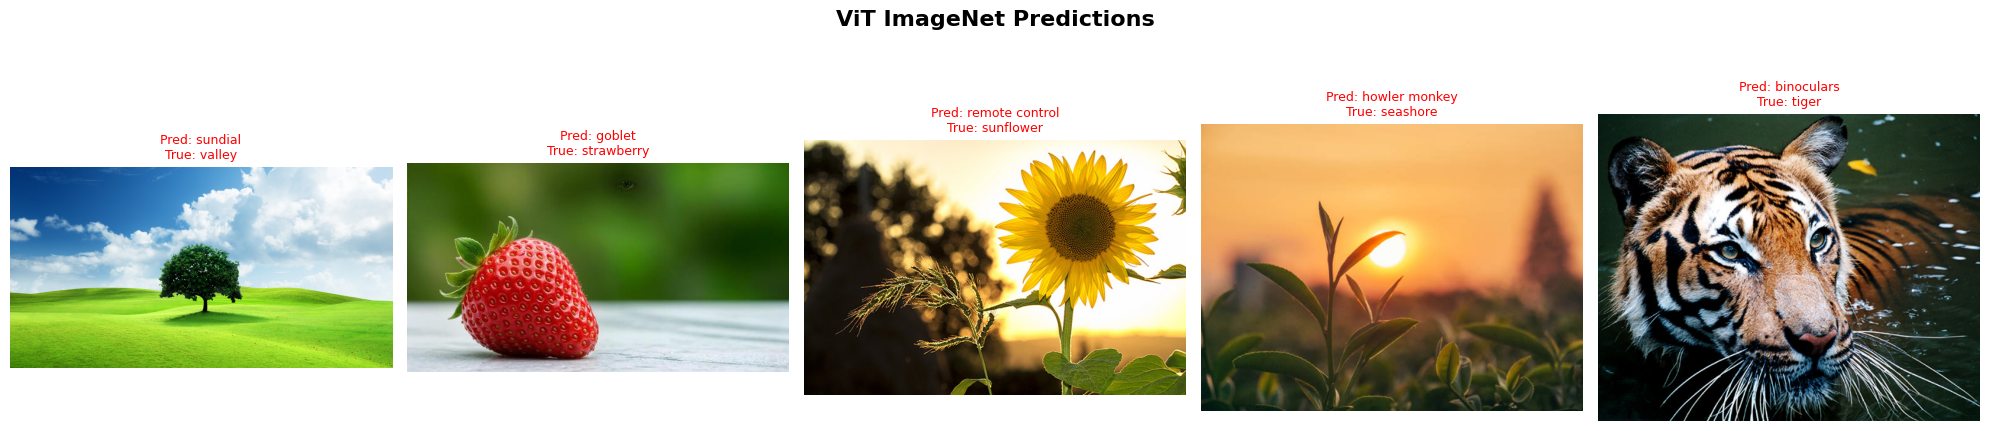

In [10]:
# Import Libraries
import os
os.environ["KERAS_BACKEND"] = "tensorflow"  # Must be set BEFORE importing keras/keras_hub

import numpy as np
import requests
import tensorflow as tf
import keras_hub
from PIL import Image
import matplotlib.pyplot as plt

# Load ViTImageClassifier without preprocessor (tensorflow-text not available on Windows)
classifier = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    num_classes=1000,
    preprocessor=None
)

# Load the ImageNet class names from the official PyTorch hub text file
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(url)
imagenet_classes = [line.strip() for line in response.text.strip().split("\n")]
print(f"Total ImageNet classes loaded: {len(imagenet_classes)}")

# Helper: load and preprocess image for ViT input
# ViT expects pixel values scaled to [-1, 1] using scale=1/127.5, offset=-1
def load_and_preprocess(filepath):
    img = Image.open(filepath).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    img_array = img_array * (1.0 / 127.5) - 1.0  # scale to [-1, 1]
    return img_array

# Path to your images folder
image_folder = r"C:\Users\fatim\OneDrive\Desktop\Applications\CV LAB images"

image_sources = [
    ("nature.jpg",     "valley"),
    ("strawberry.jpg", "strawberry"),
    ("sunflower.jpg",  "sunflower"),
    ("sunset.jpg",     "seashore"),
    ("Tiger.jpg",      "tiger"),
]

images_display = []
images = []
true_labels = []
image_names = []

for filename, true_label in image_sources:
    full_path = os.path.join(image_folder, filename)
    images_display.append(np.array(Image.open(full_path).convert("RGB")))
    images.append(load_and_preprocess(full_path))
    true_labels.append(true_label)
    image_names.append(filename)
    print(f"Loaded '{filename}': true label='{true_label}'")

# Predict classes using ViT
predicted_labels = []

for i, img_array in enumerate(images):
    img_batch = tf.expand_dims(img_array, axis=0)
    logits = classifier.predict(img_batch, verbose=0)
    pred_idx = int(np.argmax(logits, axis=-1)[0])
    pred_label = imagenet_classes[pred_idx]
    predicted_labels.append(pred_label)
    print(f"'{image_names[i]}': predicted='{pred_label}' | true='{true_labels[i]}'")

# Visualise the 5 images with their predictions
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("ViT ImageNet Predictions", fontsize=16, fontweight="bold")

for ax, img_original, pred, true in zip(axes, images_display, predicted_labels, true_labels):
    correct = true.lower() in pred.lower() or pred.lower() in true.lower()
    color = "green" if correct else "red"
    ax.imshow(img_original)
    ax.set_title(f"Pred: {pred}\nTrue: {true}", fontsize=9, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Record Your Results

Fill the table below based on your results:

| Image File   | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
| ------------ | --------------- | ------------------------------ | ----------------- |
| nature.jpg       | sundial          |   valley                          | No            |
| Strawberry.jpg    | goblet          |  strawberry                              | No            |
|Sunflower.jpg      | remote control   |  sunflower                              | No            |
|Sunset.jpg         |howler monkey       | seashore                            | No            |
| tiger.jpg         |binoculars          |tiger                             | No            |
